In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("GSE1000_series_matrix.txt", sep="\t", comment="!", header=None)
df.head()


,0,1,2,3,4,5,6,7,8,9,10
0,ID_REF,GSM15785,GSM15786,GSM15787,GSM15788,GSM15789,GSM15790,GSM15791,GSM15792,GSM15794,GSM15795
1,1007_s_at,320.4648708,232.9942945,321.1989997,299.2894447,292.0158744,247.2142626,245.7803605,222.2537593,239.0416401,305.3781325
2,1053_at,388.4570282,422.9093542,369.8441957,348.2636943,384.6797086,375.4117411,363.9898893,382.8768359,390.2117945,339.2314569
3,117_at,65.47251742,64.10611396,68.17089422,62.67997335,66.1750872,52.31132627,59.67616474,71.36348486,52.21510692,64.44750168
4,121_at,512.2466824,439.1625349,518.2708088,455.0033648,493.7479397,513.9687769,499.749209,461.6982917,441.9870046,495.7990653


In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.stats import iqr
from io import StringIO

# === STEP 1: Load Series Matrix File ===
file_path = "GSE1000_series_matrix.txt"
with open(file_path, "r") as f:
    lines = f.readlines()

# === STEP 2: Extract Expression Data ===
start_idx = next(i for i, line in enumerate(lines) if line.startswith("!series_matrix_table_begin")) + 1
try:
    end_idx = next(i for i, line in enumerate(lines) if line.startswith("!series_matrix_table_end"))
    data_lines = lines[start_idx:end_idx]
except StopIteration:
    data_lines = lines[start_idx:]

data_str = StringIO("".join(data_lines))
df_expr = pd.read_csv(data_str, sep="\t")
df_expr.rename(columns={df_expr.columns[0]: "probe_id"}, inplace=True)

# === STEP 3: Extract and Parse Metadata ===
sample_meta_lines = [line for line in lines if line.startswith("!Sample_")]
meta_dict = {}

for line in sample_meta_lines:
    parts = line.strip().split("\t")
    key = parts[0].replace("!Sample_", "")
    values = parts[1:]
    meta_dict[key] = values

sample_metadata = pd.DataFrame(meta_dict)
sample_metadata.insert(0, "sample_id", df_expr.columns[1:].tolist())

# === STEP 4: Transpose Expression Data ===
df_t = df_expr.set_index("probe_id").T
df_t.index.name = "sample_id"
df_t.reset_index(inplace=True)

# Convert all gene expression values to numeric
for col in df_t.columns[1:]:
    df_t[col] = pd.to_numeric(df_t[col], errors="coerce")

# Drop any genes (columns) with missing values
df_t.dropna(axis=1, inplace=True)

# === STEP 5: Normalize Data (Z-score) ===
scaler = StandardScaler()
gene_cols = df_t.columns[1:]
df_t[gene_cols] = scaler.fit_transform(df_t[gene_cols])

# === STEP 6: Filter Low-Variance Genes (IQR) ===
gene_iqr = df_t[gene_cols].apply(iqr)
iqr_threshold = gene_iqr.quantile(0.25)  # remove bottom 25%
high_iqr_genes = gene_iqr[gene_iqr > iqr_threshold].index
df_t = pd.concat([df_t[["sample_id"]], df_t[high_iqr_genes]], axis=1)

# === STEP 7 (Optional): Map Probe IDs to Gene Symbols ===
try:
    import mygene
    mg = mygene.MyGeneInfo()
    mapping = mg.querymany(high_iqr_genes.tolist(), scopes="reporter", fields="symbol", species="human", as_dataframe=True)
    mapping = mapping[~mapping.index.duplicated(keep='first')]
    gene_map = mapping["symbol"].to_dict()

    # Rename columns to gene symbols if available
    df_t.rename(columns=gene_map, inplace=True)
except ImportError:
    print("mygene not installed. Skipping gene annotation. Run `pip install mygene` to enable it.")

# === STEP 8: Save Clean Dataset and Metadata ===
df_t.to_csv("GSE1000_expression_cleaned.csv", index=False)
sample_metadata.to_csv("GSE1000_metadata.csv", index=False)

print("✅ Preprocessing complete")
print("Expression data shape:", df_t.shape)
print("Metadata shape:", sample_metadata.shape)


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
816 input query terms found dup hits:	[('1007_s_at', 2), ('1294_at', 2), ('200003_s_at', 2), ('200012_x_at', 4), ('200016_x_at', 2), ('200
986 input query terms found no hit:	['201205_at', '201265_at', '202015_x_at', '202091_at', '202280_at', '202881_x_at', '203326_x_at', '2


✅ Preprocessing complete
Expression data shape: (10, 16713)
Metadata shape: (10, 27)



=== Top 20 by Variance ===


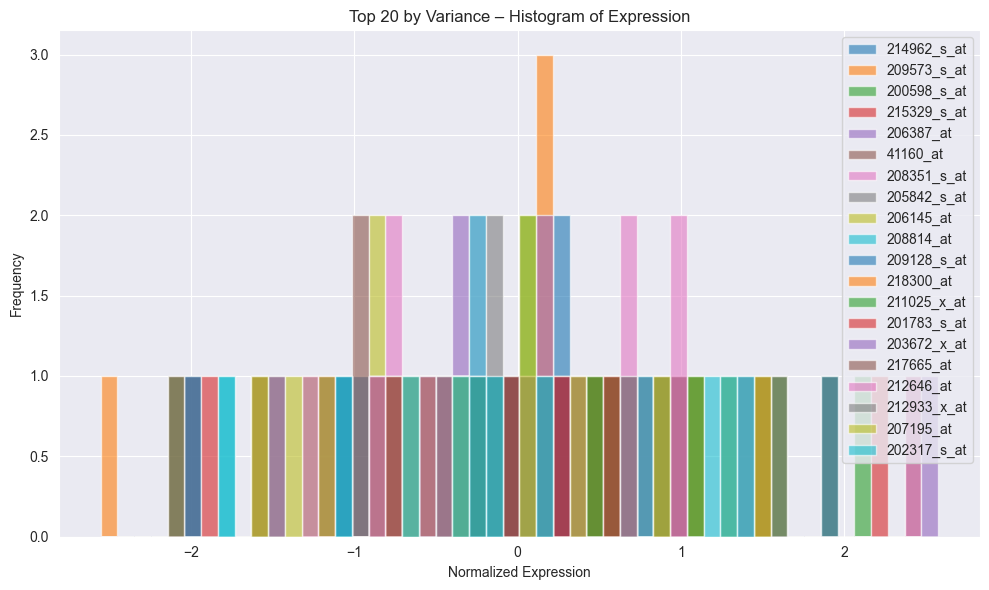

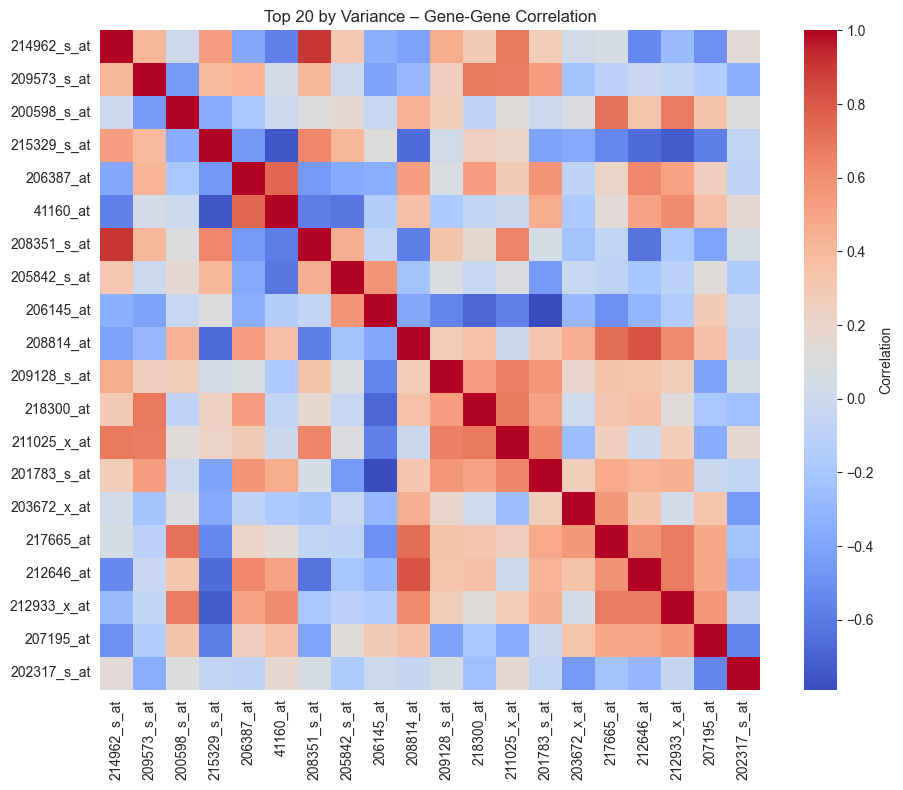


=== Top 20 by Differential Expression ===


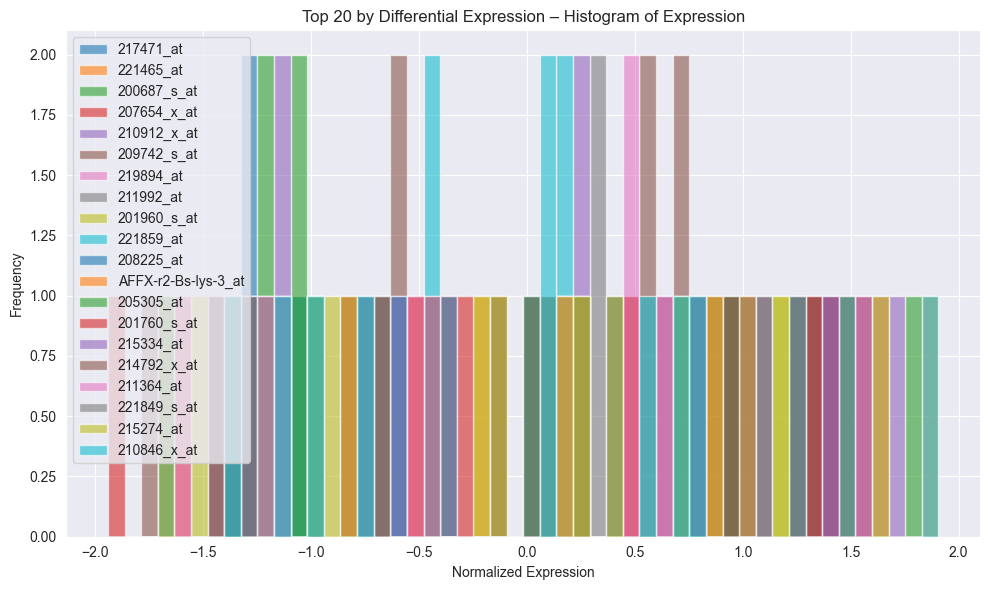

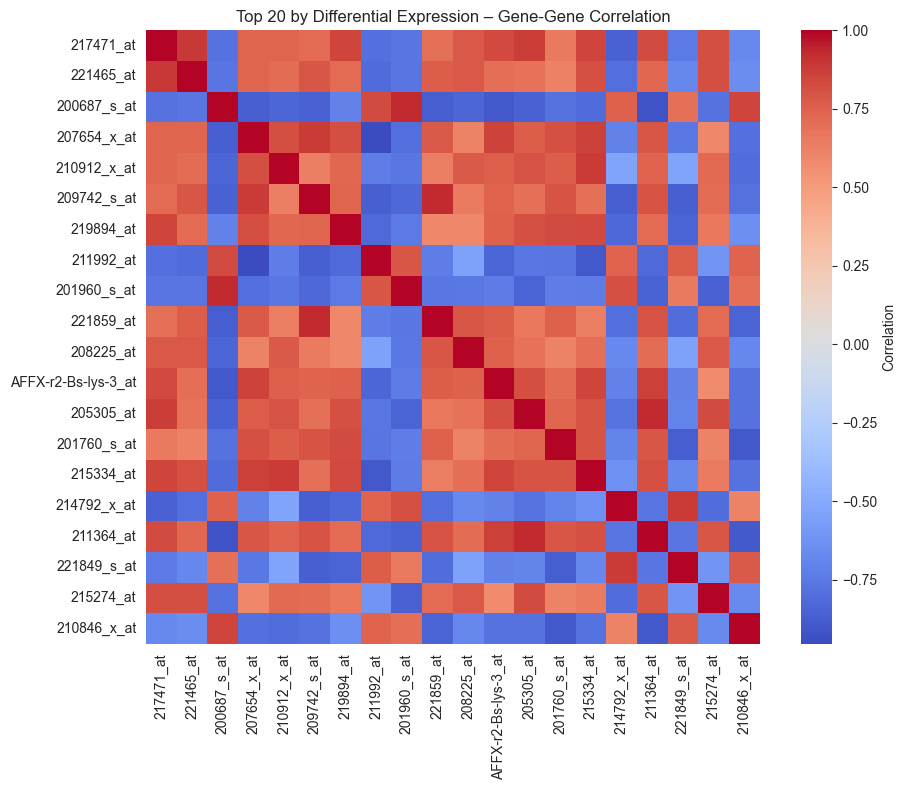


=== Top 20 by Random Forest Importance ===


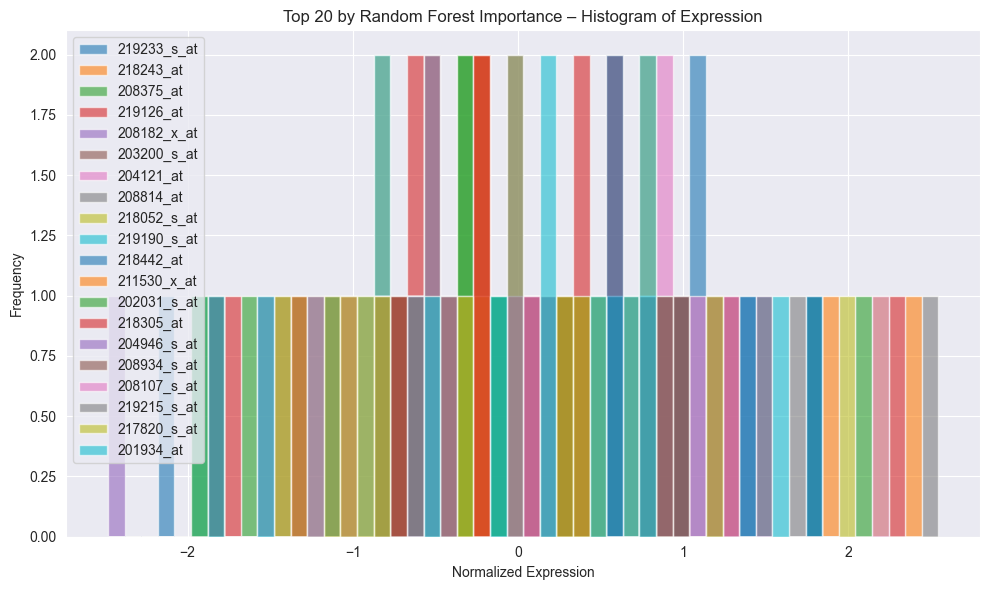

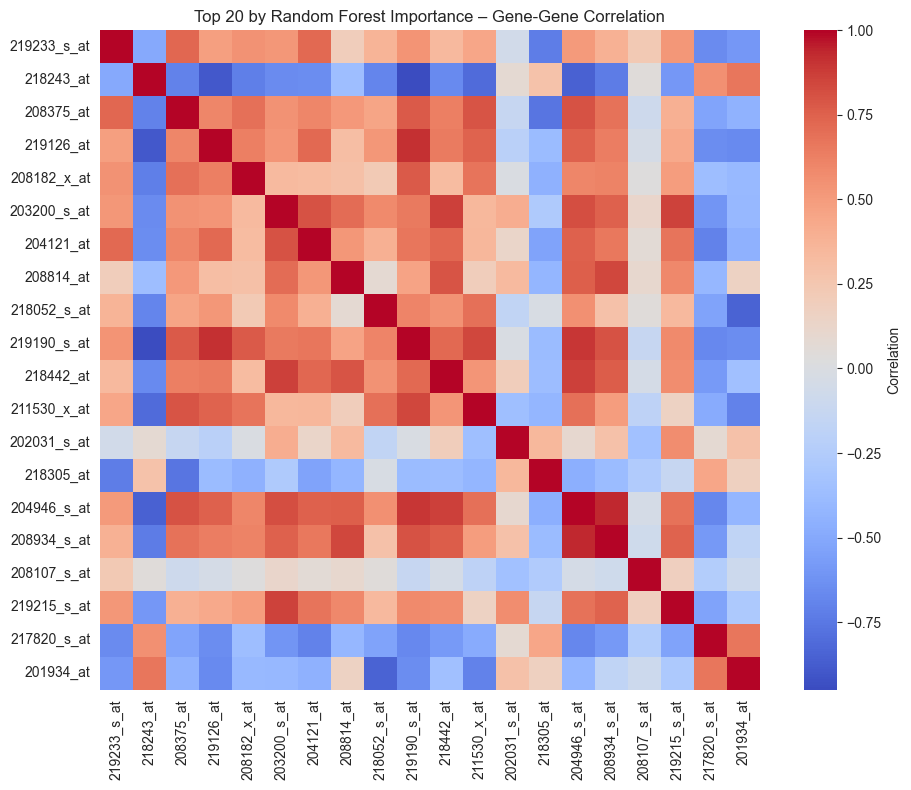

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed data
df_t = pd.read_csv("GSE1000_clean_normalized.csv")
df_t["condition"] = ['6h'] * 5 + ['32h'] * 5

# Load DE and RF importance tables
de_df = pd.read_csv("differential_expression_results.csv")
rf_df = pd.read_csv("random_forest_top20_genes.csv", names=["gene", "importance"])

# Get all numeric gene columns
gene_cols = [col for col in df_t.columns if col not in ["sample_id", "condition"]]

# === Method 1: Top 20 by Variance ===
var_genes = df_t[gene_cols].var().sort_values(ascending=False).head(20).index.tolist()

# === Method 2: Top 20 by DE p-value ===
de_top_genes = (
    de_df.sort_values("p_value")
         .head(20)["gene"]
         .tolist()
)

# === Method 3: Top 20 by RF importance ===
rf_top_genes = rf_df["gene"].dropna().astype(str).tolist()

# Combine methods for display
selection_methods = {
    "Top 20 by Variance": var_genes,
    "Top 20 by Differential Expression": de_top_genes,
    "Top 20 by Random Forest Importance": rf_top_genes,
}

# === Plot Function ===
def plot_hist_and_heatmap(genes, title_prefix):
    # Histogram
    df_t[genes].plot.hist(bins=50, alpha=0.6, figsize=(10, 6))
    plt.title(f"{title_prefix} – Histogram of Expression")
    plt.xlabel("Normalized Expression")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_t[genes].corr(), cmap="coolwarm", square=True, cbar_kws={"label": "Correlation"})
    plt.title(f"{title_prefix} – Gene-Gene Correlation")
    plt.tight_layout()
    plt.show()

# === Run all three ===
for name, gene_list in selection_methods.items():
    print(f"\n=== {name} ===")
    plot_hist_and_heatmap(gene_list, name)


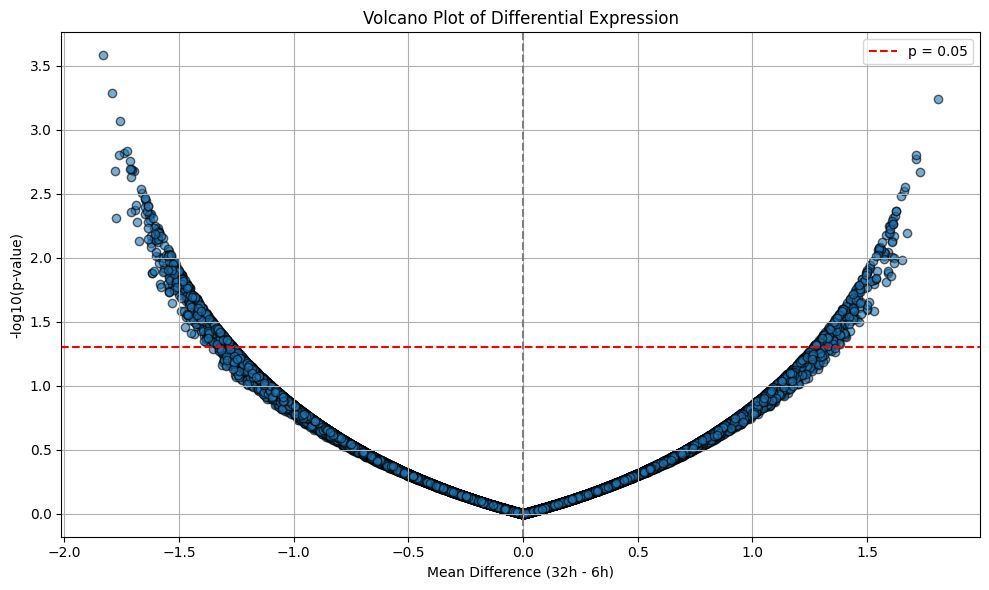

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# Load the dataset with condition labels
df = pd.read_csv("GSE1000_clean_normalized.csv")
df['condition'] = ['6h'] * 5 + ['32h'] * 5

# Separate groups
group_6h = df[df['condition'] == '6h']
group_32h = df[df['condition'] == '32h']

# Prepare result storage
results = []

# Run t-test for each gene (skip non-gene columns)
# Filter numeric gene columns only
gene_cols = df.select_dtypes(include=[np.number]).columns

# Perform t-tests and compute fold changes
results = []
for gene in gene_cols:
    t_stat, p_val = ttest_ind(group_6h[gene], group_32h[gene], equal_var=False)
    mean_diff = group_32h[gene].mean() - group_6h[gene].mean()
    results.append({
        "gene": gene,
        "p_value": p_val,
        "log2_fold_change": mean_diff
    })

# Convert to DataFrame
de_df = pd.DataFrame(results)
de_df['-log10_pval'] = -np.log10(de_df['p_value'])

# Save and plot
de_df.to_csv("differential_expression_results.csv", index=False)

# Volcano plot
plt.figure(figsize=(10, 6))
plt.scatter(de_df["log2_fold_change"], de_df["-log10_pval"], alpha=0.6, edgecolor='k')
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Volcano Plot of Differential Expression")
plt.xlabel("Mean Difference (32h - 6h)")
plt.ylabel("-log10(p-value)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


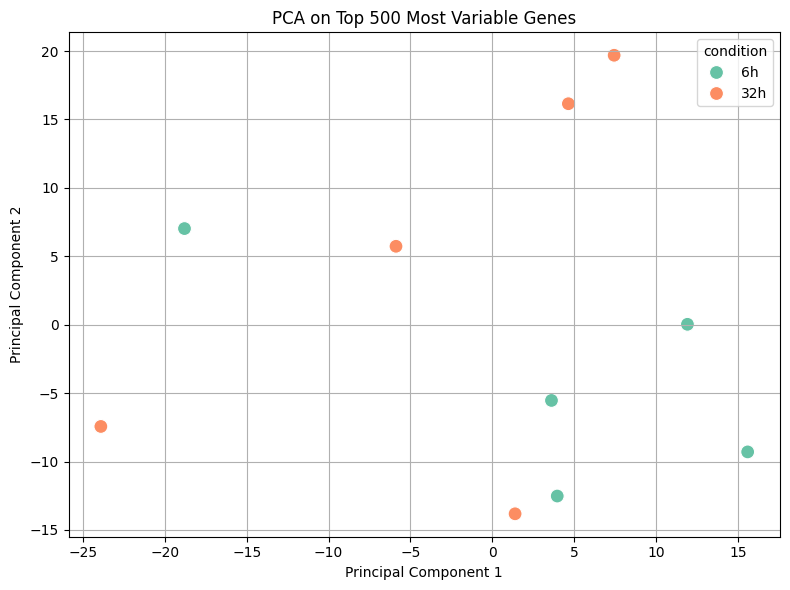

In [13]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load your normalized data
df = pd.read_csv("GSE1000_clean_normalized.csv")

# Add condition labels manually (5x 6h, 5x 32h)
df["condition"] = ['6h'] * 5 + ['32h'] * 5

# Keep only numeric gene columns
gene_cols = [col for col in df.columns if col not in ["sample_id", "condition"]]

# === Step 1: Compute mean and variance per gene ===
gene_stats = pd.DataFrame({
    "mean": df[gene_cols].mean(),
    "variance": df[gene_cols].var()
})
gene_stats.sort_values("variance", ascending=False, inplace=True)

# === Step 2: Select top N most variable genes ===
top_n = 500
top_genes = gene_stats.head(top_n).index
df_top = df[["sample_id", "condition"] + list(top_genes)].copy()

# === Step 3: Optional PCA to visualize separability again ===
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_top[top_genes])
df_top.loc[:, "PC1"] = pca_result[:, 0]
df_top.loc[:, "PC2"] = pca_result[:, 1]

# PCA plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_top, x="PC1", y="PC2", hue="condition", palette="Set2", s=100)
plt.title("PCA on Top 500 Most Variable Genes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 4: Save reduced dataset ===
df_top.to_csv("top500_variable_genes.csv", index=False)



Linear SVM
----------
Accuracy: 0.667
              precision    recall  f1-score   support

          6h       0.67      1.00      0.80         2
         32h       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



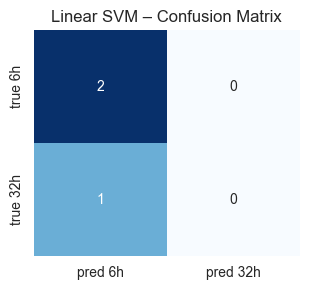


RBF SVM
-------
Accuracy: 0.333
              precision    recall  f1-score   support

          6h       0.00      0.00      0.00         2
         32h       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



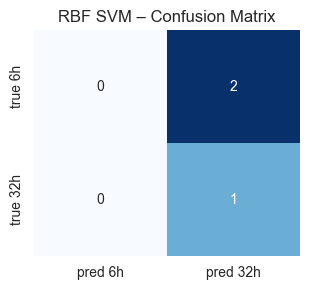

Summary accuracy:
  Linear SVM : 0.667
  RBF SVM    : 0.333


In [8]:
# Day‑4 – Classification (SVM)
# ------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)
import seaborn as sns
import matplotlib.pyplot as plt

# 1) --------------------------------------------------------
# LOAD the reduced feature matrix you saved yesterday
df = pd.read_csv("top500_variable_genes.csv")
# Encode the label
y = df["condition"].map({"6h": 0, "32h": 1}).values
X = df.drop(["sample_id", "condition", "PC1", "PC2"], axis=1)

# 2) --------------------------------------------------------
# Train / Test split (stratified so the 5‑vs‑5 balance is kept)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42,
)

# 3) --------------------------------------------------------
# Two pipelines:  (i) linear SVM  (ii) RBF‑kernel SVM
# Data were z‑scored already, but including a scaler inside the
# pipeline never hurts and avoids surprises if you swap datasets.
pipelines = {
    "Linear SVM": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(random_state=42)),
        ]
    ),
    "RBF SVM": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", C=1, gamma="scale", random_state=42)),
        ]
    ),
}

results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("-" * len(name))
    print("Accuracy:", round(acc, 3))
    print(classification_report(y_test, y_pred, target_names=["6h", "32h"], zero_division=0))

    # Confusion‑matrix heat‑map
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(3.2, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        cmap="Blues",
        xticklabels=["pred 6h", "pred 32h"],
        yticklabels=["true 6h", "true 32h"],
    )
    plt.title(f"{name} – Confusion Matrix")
    plt.tight_layout()
    plt.show()



# 4) --------------------------------------------------------
print("Summary accuracy:")
for k, v in results.items():
    print(f"  {k:<10} : {v:.3f}")


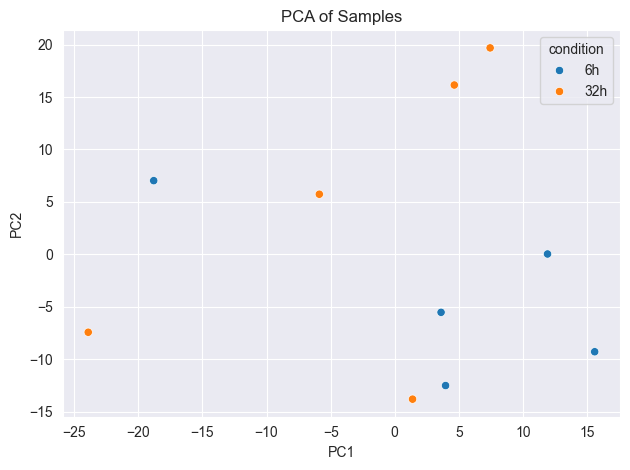


Linear SVM
----------
Cross-validated accuracy scores: [0.5 0.5 0.5 1.  0. ]
Mean CV accuracy: 0.5

RBF SVM
-------
Cross-validated accuracy scores: [0.5 1.  0.5 1.  0. ]
Mean CV accuracy: 0.6

Summary accuracy:
  Linear SVM : 0.500
  RBF SVM    : 0.600


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
import seaborn as sns
import matplotlib.pyplot as plt

# 1) --------------------------------------------------------
# LOAD the reduced feature matrix
df = pd.read_csv("top500_variable_genes.csv")

# PCA visualization (optional)
sns.scatterplot(x="PC1", y="PC2", hue="condition", data=df)
plt.title("PCA of Samples")
plt.tight_layout()
plt.show()

# Prepare features and labels
y = df["condition"].map({"6h": 0, "32h": 1}).values
X = df.drop(["sample_id", "condition", "PC1", "PC2"], axis=1)

# 2) --------------------------------------------------------
# Define pipelines
pipelines = {
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(random_state=42, max_iter=10000)),
    ]),
    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=1, gamma="scale", random_state=42)),
    ]),
}

# 3) --------------------------------------------------------
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in pipelines.items():
    print(f"\n{name}")
    print("-" * len(name))
    
    # Run CV
    scores = cross_val_score(pipe, X, y, cv=cv)
    results[name] = scores.mean()
    
    print("Cross-validated accuracy scores:", scores)
    print("Mean CV accuracy:", round(scores.mean(), 3))

# 4) --------------------------------------------------------
# Final summary
print("\nSummary accuracy:")
for k, v in results.items():
    print(f"  {k:<10} : {v:.3f}")


5‑fold CV accuracies: [0.5 0.5 0.5 1.  0. ]
Mean CV accuracy    : 0.5


C:\Users\dwije\AppData\Local\Temp\ipykernel_21516\986252457.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\dwije\AppData\Local\Temp\ipykernel_21516\986252457.py:58: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dwije\OneDrive\Desktop\University Content\comp3222 - Computational Biology\project3\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


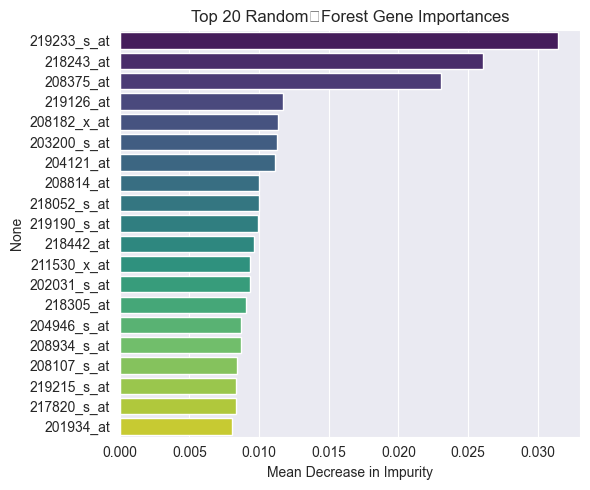


Top‑20 gene list written to  random_forest_top20_genes.csv


In [10]:
# Day‑5  –  Random Forest & Important Genes
# ------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
TOP_N_IMPORTANCE = 20        # how many genes do we want to display/save?

# 1) --------------------------------------------------------
df = pd.read_csv("top500_variable_genes.csv")
y  = df["condition"].map({"6h": 0, "32h": 1}).values
X  = df.drop(columns=["sample_id", "condition", "PC1", "PC2"])

# 2) --------------------------------------------------------
# Fit a reasonably large forest – with so few samples over‑fitting is still possible,
# so we keep max_depth small.
rf = RandomForestClassifier(
        n_estimators=1000,
        max_depth=3,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=RANDOM_STATE,
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X, y, cv=cv)

print("5‑fold CV accuracies:", cv_scores.round(3))
print("Mean CV accuracy    :", cv_scores.mean().round(3))

# Train on the **whole** data set so we can extract importances
rf.fit(X, y)

# 3) --------------------------------------------------------
# Collect & sort importances
importances = (
    pd.Series(rf.feature_importances_, index=X.columns)
      .sort_values(ascending=False)
)

top_imp = importances.head(TOP_N_IMPORTANCE)

# 4) --------------------------------------------------------
# ── Plot ────────────────────────────────────────────────────
plt.figure(figsize=(6, 5))
sns.barplot(
    y=top_imp.index,
    x=top_imp.values,
    palette="viridis",
)
plt.xlabel("Mean Decrease in Impurity")
plt.title(f"Top {TOP_N_IMPORTANCE} Random‑Forest Gene Importances")
plt.tight_layout()
plt.show()

# 5) --------------------------------------------------------
# Save for later biological interpretation
top_imp.to_csv("random_forest_top20_genes.csv", header=["importance"])
print("\nTop‑20 gene list written to  random_forest_top20_genes.csv")


In [11]:
# Day‑6  –  LDA & Model‑comparison table
# ------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
N_SPLITS = 5

# -----------------------------------------------------------------
df = pd.read_csv("top500_variable_genes.csv")
y  = df["condition"].map({"6h": 0, "32h": 1}).values
X  = df.drop(columns=["sample_id", "condition", "PC1", "PC2"])

# -----------------------------------------------------------------
pipelines = {
    "LDA": Pipeline([
        ("scaler", StandardScaler()),   # LDA likes unit variance too
        ("clf", LinearDiscriminantAnalysis()),
    ]),
    "Linear‑SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(random_state=RANDOM_STATE, max_iter=10000)),
    ]),
    "RBF‑SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=1, gamma="scale", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=1000,
        max_depth=3,
        max_features="sqrt",
        random_state=RANDOM_STATE,
    ),
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
summary = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=cv)
    summary[name] = {
        "mean_acc": scores.mean(),
        "std": scores.std(),
        "fold_scores": np.round(scores, 2),
    }
    print(f"{name:12s}  mean={scores.mean():.3f}  std={scores.std():.3f}  folds={np.round(scores,2)}")

# -----------------------------------------------------------------
# Build a neat comparison table
cmp = (
    pd.DataFrame(summary)
      .T[["mean_acc", "std"]]
      .sort_values("mean_acc", ascending=False)
      .rename(columns={"mean_acc": "CV Accuracy (mean)", "std": "± SD"})
      .style.format({"CV Accuracy (mean)": "{:.3f}", "± SD": "{:.3f}"})
)
cmp
 

LDA           mean=0.700  std=0.400  folds=[1.  1.  0.5 1.  0. ]
Linear‑SVM    mean=0.500  std=0.316  folds=[0.5 0.5 0.5 1.  0. ]
RBF‑SVM       mean=0.600  std=0.374  folds=[0.5 1.  0.5 1.  0. ]
Random Forest  mean=0.500  std=0.316  folds=[0.5 0.5 0.5 1.  0. ]


,CV Accuracy (mean),± SD
LDA,0.700,0.400
RBF‑SVM,0.600,0.374
Linear‑SVM,0.500,0.316
Random Forest,0.500,0.316


Adjusted Rand Index : 0.280
Homogeneity         : 0.278
Adj. Mutual Info    : 0.210

Contingency table
           cluster 0  cluster 1
true 6h           4          1
true 32h          1          4


C:\Users\dwije\AppData\Local\Temp\ipykernel_21516\2828812513.py:70: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dwije\OneDrive\Desktop\University Content\comp3222 - Computational Biology\project3\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


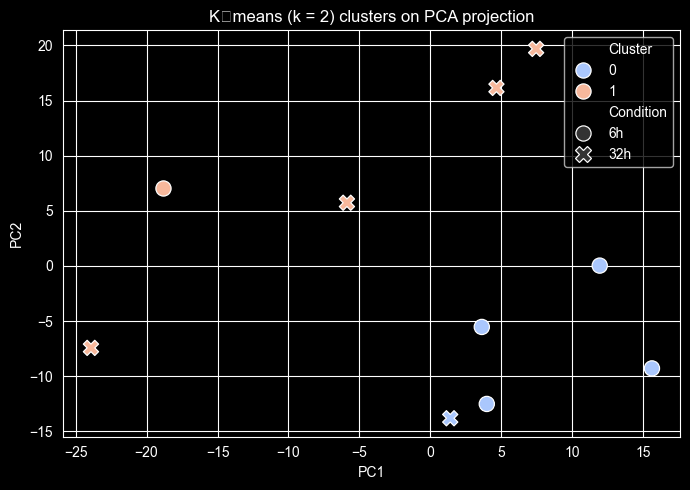

In [12]:
# Day‑7 – K‑means Clustering vs. True Labels
# ------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    homogeneity_score,
    adjusted_mutual_info_score,
    confusion_matrix,
)
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42
plt.style.use("dark_background")

# -----------------------------------------------------------------
df = pd.read_csv("top500_variable_genes.csv")
y_true = df["condition"].map({"6h": 0, "32h": 1}).values
X       = df.drop(columns=["sample_id", "condition", "PC1", "PC2"])

# optional: re‑scale once more (K‑means is distance‑based)
X_scaled = StandardScaler().fit_transform(X)

# -----------------------------------------------------------------
kmeans = KMeans(n_clusters=2, n_init=50, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_scaled)

# -----------------------------------------------------------------
# Metrics
ari  = adjusted_rand_score(y_true, cluster_labels)
hom  = homogeneity_score(y_true, cluster_labels)
ami  = adjusted_mutual_info_score(y_true, cluster_labels)
print(f"Adjusted Rand Index : {ari:.3f}")
print(f"Homogeneity         : {hom:.3f}")
print(f"Adj. Mutual Info    : {ami:.3f}")

# Simple 2×2 table
ct = pd.DataFrame(
    confusion_matrix(y_true, cluster_labels),
    index=["true 6h", "true 32h"],
    columns=["cluster 0", "cluster 1"],
)
print("\nContingency table\n", ct)

# -----------------------------------------------------------------
# Visualise clusters on PCA (same projection for fairness)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
df_plot = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "Cluster": cluster_labels.astype(str),
    "Condition": df["condition"],
})
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    style="Condition",
    palette="coolwarm",
    data=df_plot,
    s=120,
)
plt.title("K‑means (k = 2) clusters on PCA projection")
plt.tight_layout()
plt.show()


[DE Filter] Mapped probes to 2721 unique gene symbols


C:\Users\dwije\AppData\Local\Temp\ipykernel_21516\2630155768.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, y="name", x=-np.log10(subset["p_value"]), palette="viridis")


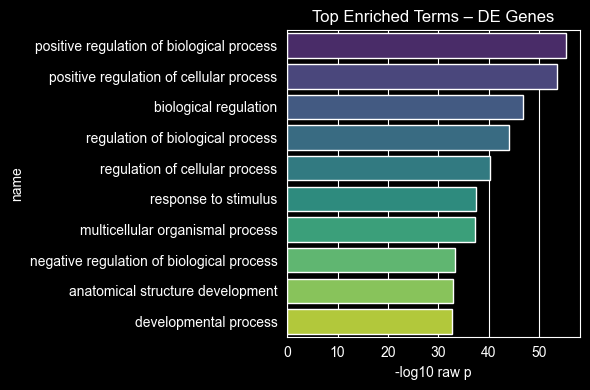

[RF Top 20] Mapped probes to 20 unique gene symbols


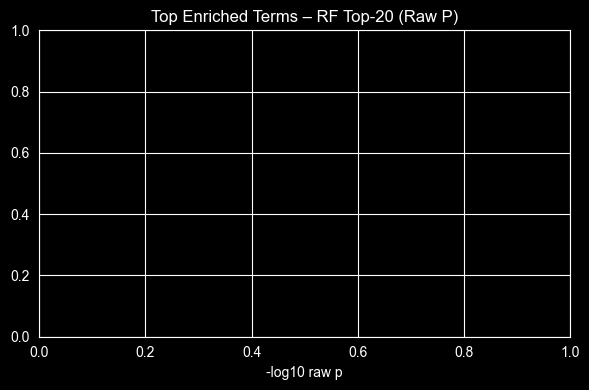

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from gprofiler.gprofiler import GProfiler
import gzip, os, requests

# Define base directory
base = r"C:\Users\dwije\OneDrive\Desktop\University Content\comp3222 - Computational Biology\project3"

# Annotation file
annot_file = os.path.join(base, "GPL96.annot")
if not os.path.exists(annot_file):
    url = "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL96/annot/GPL96.annot.gz"
    annot = gzip.decompress(requests.get(url, timeout=30).content)
    with open(annot_file, "wb") as fh:
        fh.write(annot)

# Read annotation
gpl = pd.read_csv(
    annot_file,
    sep="\t",
    skiprows=27,
    usecols=["ID", "Gene symbol"],
    dtype=str
).rename(columns={"ID": "probe", "Gene symbol": "symbol"})

# Initialize g:Profiler client
gp = GProfiler(return_dataframe=True)

# ----------------------------------------------------------
# OPTION 1 – Top 100 RF probes (you'll need to expand your CSV to include this)
# For now, skip this unless you have "random_forest_importances.csv"
# ----------------------------------------------------------

# ----------------------------------------------------------
# OPTION 2 – Differential Expression Filtered List
de_file = os.path.join(base, "differential_expression_results.csv")
de_df = pd.read_csv(de_file)
de_filtered = de_df[(de_df["p_value"] < 0.05) | (abs(de_df["log2_fold_change"]) > 1)]
de_probes = de_filtered["gene"]

mapped_de = gpl[gpl["probe"].isin(de_probes)]
symbols_de = mapped_de["symbol"].dropna().unique().tolist()
print(f"[DE Filter] Mapped probes to {len(symbols_de)} unique gene symbols")

if len(symbols_de) >= 3:
    enr_de = gp.profile(organism="hsapiens", query=symbols_de, sources=["GO:BP", "KEGG", "REAC"])
    de_outfile = os.path.join(base, "enrichment_de_genes.csv")
    enr_de.to_csv(de_outfile, index=False)

    subset = enr_de.sort_values("p_value").head(10)
    plt.figure(figsize=(6, 4))
    sns.barplot(data=subset, y="name", x=-np.log10(subset["p_value"]), palette="viridis")
    plt.xlabel("-log10 raw p")
    plt.title("Top Enriched Terms – DE Genes")
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------
# OPTION 3 – RF Top 20, raw-p visualisation
rf20_file = os.path.join(base, "random_forest_top20_genes.csv")
rf20_df = pd.read_csv(rf20_file, header=None, names=["probe", "importance"])
rf20_probes = rf20_df["probe"].tolist()

mapped_rf20 = gpl[gpl["probe"].isin(rf20_probes)]
symbols_rf20 = mapped_rf20["symbol"].dropna().unique().tolist()
print(f"[RF Top 20] Mapped probes to {len(symbols_rf20)} unique gene symbols")

if len(symbols_rf20) >= 3:
    enr_rf20 = gp.profile(organism="hsapiens", query=symbols_rf20, sources=["GO:BP", "KEGG"])
    rf20_outfile = os.path.join(base, "enrichment_rf20.csv")
    enr_rf20.to_csv(rf20_outfile, index=False)

    subset = enr_rf20.sort_values("p_value").head(10)
    plt.figure(figsize=(6, 4))
    sns.barplot(data=subset, y="name", x=-np.log10(subset["p_value"]), palette="magma_r")
    plt.xlabel("-log10 raw p")
    plt.title("Top Enriched Terms – RF Top-20 (Raw P)")
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------
# Final fallback message
if len(symbols_rf20) < 3:
    print("Too few genes for enrichment with RF Top-20.")


In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# --- Load data ---
df = pd.read_csv("top500_variable_genes.csv")
de_df = pd.read_csv("differential_expression_results.csv")

# --- Setup ---
X = df.drop(columns=["sample_id", "condition", "PC1", "PC2"])
y = df["condition"].map({"6h": 0, "32h": 1}).values
gene_cols = X.columns

# === 1. Top N Most Variable Genes ===
gene_variance = df[gene_cols].var()
top_var_genes = gene_variance.sort_values(ascending=False).head(500).index

# === 2. Differential Expression Filter (p < 0.05 and |log2FC| > 1) ===
de_filtered = de_df[
    (de_df["p_value"] < 0.05) &
    (abs(de_df["log2_fold_change"]) > 1)
    ]["gene"]
top_de_genes = de_filtered.tolist()

# === 3. Random Forest Importance Filter (Top 100 genes) ===
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=3,
    random_state=42
)
rf.fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=gene_cols)
top_rf_genes = rf_importances.sort_values(ascending=False).head(100).index

# === 4. Combine All Three (Intersection or Union) ===
# INTERSECTION (genes selected by all 3 methods)
selected_genes = list(set(top_var_genes) & set(top_de_genes) & set(top_rf_genes))

# Or use UNION if you want a larger gene pool:
# selected_genes = list(set(top_var_genes) | set(top_de_genes) | set(top_rf_genes))

# --- Save selected gene expression matrix ---
final_df = df[["sample_id", "condition"] + selected_genes]
final_df.to_csv("selected_genes_combined.csv", index=False)

print(f"Selected {len(selected_genes)} genes using intersection of all 3 methods.")


Selected 15 genes using intersection of all 3 methods.
